In [1]:
from metalearning_benchmarks.line_sine1d_benchmark import LineSine1D
from metalearning_benchmarks.sinusoid1d_benchmark import Sinusoid1D
from metalearning_benchmarks.linear1d_benchmark import Linear1D
import matplotlib.pyplot as plt
from torch.optim import Adam, AdamW

# Encoder: Aggregates context (X_ctx, Y_ctx) -> r
from sampling.masked.source import (
    MaskedSetEncoder,
    SetDecoder,
    MaskedMetaNETSSampler,
    train_meta_nets_final,
)

benchmark = LineSine1D(
    n_task=256,  # number of tasks
    n_datapoints_per_task=64,  # number of evaluations per task
    output_noise=0.01,  # Gaussian noise with std-dev 0.01
    seed_task=0,
    seed_x=0,
    seed_noise=0,
)

Generating tasks: 100%|██████████| 256/256 [00:00<00:00, 327860.10it/s]


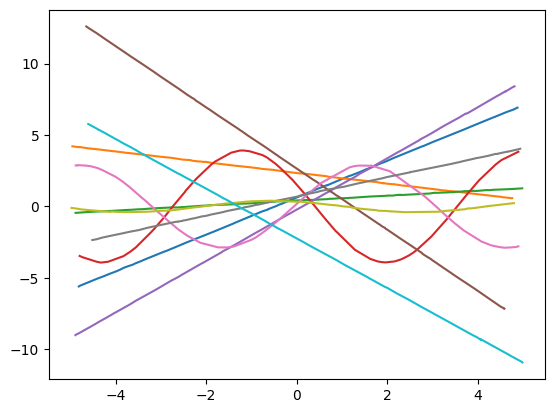

In [2]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(10):
    task = benchmark.get_task_by_index(i)  # (128,1,1)

    x = task.x.squeeze()  # (128,)
    y = task.y.squeeze()  # (128,)

    indices = np.argsort(x)
    x = x[indices]
    y = y[indices]

    plt.plot(x, y)

plt.show()

In [3]:
import torch


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
from sampling.meta.loader import get_meta_loader


loader = get_meta_loader(benchmark, batch_size=512, context_size=10)

In [5]:
# --- 1. Initialize Components ---


from sampling.masked.source import AttentionSetEncoder


x_dim = 1
y_dim = 1
z_dim = 2
r_dim = 32


# set_encoder = MaskedSetEncoder(x_dim=x_dim, y_dim=y_dim, r_dim=r_dim).to(
#     device
# )  #
set_encoder = AttentionSetEncoder(x_dim=x_dim, y_dim=y_dim, r_dim=r_dim).to(device)

# Decoder: Predicts target (z, X_target) -> Y_target
# Note: The decoder treats 'z' as the representation.
# If SetDecoder expects 'r_dim' as input size, we pass z_dim.
set_decoder = SetDecoder(x_dim=x_dim, y_dim=y_dim, z_dim=z_dim).to(device)

# Sampler: Manages Drift, F-Net, and Replay Buffer
# We pass the encoder/decoder so the sampler can compute internal energies
nets = MaskedMetaNETSSampler(
    set_encoder=set_encoder,
    set_decoder=set_decoder,
    z_dim=z_dim,
    r_dim=r_dim,
    sigma=0.7,  # 0.5,  # Controls the "tightness" of the likelihood
    epsilon=1,  # 2.0,  # Controls the diffusion noise level
).to(device)

In [6]:
lr_nets: float = 5e-4
lr_model: float = 5e-4

# OPT 1: Inference / Sampler Dynamics
# Trains the "How to Sample" components:
# - Drift & F-Net: Learn the transport dynamics.
# - Encoder: Learns to parameterize those dynamics based on data (x, y).
# Minimizes PINN Residual.
opt_nets = AdamW(
    list(nets.drift_net.parameters())
    + list(nets.f_net.parameters())
    + list(set_encoder.parameters()),  # <--- MOVED HERE
    lr=lr_nets,
)

# OPT 2: Generative Model
# Trains the "What is Likelihood" component:
# - Decoder: Maximizes p(y | x, z).
# Minimizes Reconstruction Error.
opt_model = AdamW(
    list(set_decoder.parameters()),  # Decoder only
    lr=lr_model,
)

In [9]:
# from sampling.meta.train import train_meta_nets, train_meta_nets_dyn

_ = train_meta_nets_final(
    device,
    loader,
    nets,
    set_encoder,
    set_decoder,
    opt_nets,
    opt_model,
    epochs=500,
    pinn_update_freq=1,  # 10,
    train_decoder=True,
)

# train_meta_nets_dyn(
#     device,
#     loader,
#     nets,
#     set_encoder,
#     set_decoder,
#     opt_nets,
#     opt_model,
#     epochs=3000,
# )

Starting Meta-Training...
torch.Size([10000, 1])
Epoch 1: PINN=2433.03, Recon=5.2561
torch.Size([10000, 1])
Epoch 2: PINN=3395.41, Recon=1.7646
torch.Size([10000, 1])
Epoch 3: PINN=14325.12, Recon=1.3492
torch.Size([10000, 1])
Epoch 4: PINN=21041.80, Recon=1.9328
torch.Size([10000, 1])
Epoch 5: PINN=9334.50, Recon=3.9309
torch.Size([10000, 1])
Epoch 6: PINN=14274.08, Recon=1.5239
torch.Size([10000, 1])
Epoch 7: PINN=12350.66, Recon=1.9419
torch.Size([10000, 1])
Epoch 8: PINN=10189.02, Recon=1.8979
torch.Size([10000, 1])
Epoch 9: PINN=15959.76, Recon=1.9187
torch.Size([10000, 1])
Epoch 10: PINN=11371.45, Recon=3.3372
torch.Size([10000, 1])
Epoch 11: PINN=1280.18, Recon=9.4522
torch.Size([10000, 1])
Epoch 12: PINN=18365.50, Recon=1.6417
torch.Size([10000, 1])
Epoch 13: PINN=13030.09, Recon=4.9129
torch.Size([10000, 1])
Epoch 14: PINN=4509.12, Recon=2.5876
torch.Size([10000, 1])
Epoch 15: PINN=10722.68, Recon=1.6676
torch.Size([10000, 1])
Epoch 16: PINN=1809.35, Recon=2.8523
torch.Size([1

In [9]:
# save model
torch.save(set_encoder.state_dict(), "set_encoder.pt")
torch.save(set_decoder.state_dict(), "set_decoder.pt")
torch.save(nets.state_dict(), "nets.pt")

In [7]:
# load models
set_encoder.load_state_dict(torch.load("set_encoder.pt"))
set_decoder.load_state_dict(torch.load("set_decoder.pt"))
nets.load_state_dict(torch.load("nets.pt"))

<All keys matched successfully>

In [9]:
from sampling.meta.vis import visualize_task_eval

eval_loader = get_meta_loader(benchmark, batch_size=1, context_size=3)

# 2. Fetch a single batch
# iter() creates an iterator, and next() grabs the first batch
batch_data = next(iter(eval_loader))

# Unpack the batch.
# Each tensor has shape: (Batch_Size, N_Points, Dim)
# e.g., (4, 10, 1) for context, (4, 128, 1) for target
x_ctx_batch, y_ctx_batch, x_tar_batch, y_tar_batch = batch_data

# 3. Select the first task in the batch (Index 0)
# We slice [0] to get shape (N_Points, Dim)
x_ctx_eval = x_ctx_batch[0].to(device)
y_ctx_eval = y_ctx_batch[0].to(device)
x_tar_eval = x_tar_batch[0].to(device)
y_tar_eval = y_tar_batch[0].to(device)

visualize_task_eval(
    nets,
    set_encoder,
    set_decoder,
    x_ctx_eval,
    y_ctx_eval,
    x_tar_eval,
    y_tar_eval,
    device,
    num_samples=512,
    save_path="eval_task_512.png",
)

TypeError: MaskedMetaNETSSampler.sample_posterior() missing 1 required positional argument: 'mask'